# 📊 Exploratory Data Analysis (EDA) — Heart Disease Dataset

This notebook explores a heart disease dataset to understand the underlying patterns in patient
demographics, clinical measurements, symptoms, and their relationship with the target variable
(`HeartDisease`). The analysis covers:

1. **Data Quality & Anomaly Detection** — missing values, duplicates, data types, anomalies
2. **Demographics** — age and gender distribution
3. **Clinical Measurements** — resting blood pressure, cholesterol, resting ECG, MaxHR, fasting blood sugar, and their relationship with heart disease
4. **Symptoms** — chest pain type, exercise-induced angina, oldpeak, and ST slope
5. **Target & Correlation** — class balance and feature correlation
6. **Bivariate Analysis** — statistical hypothesis testing with effect sizes

For categorical comparisons that would normally use interactive filters (e.g. by gender or diagnosis
status), each condition is shown sequentially as separate plots so that every insight is captured
without requiring interactive widgets.

---
## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## 2. Load Dataset



In [3]:
df = pd.read_csv("../Data/heart.csv")  # replace with your dataset path
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


---
## 3. Data Quality & Anomaly Detection

This section covers:
- **Missing values** — checking for null data
- **Duplicate rows** — identifying redundant entries
- **Data types** — confirming each column has the correct type
- **Descriptive statistics** — overview of numerical feature distributions
- **Categorical value counts** — checking unique values in categorical columns
- **Anomaly detection** — flagging suspicious values like zero cholesterol or blood pressure

In [4]:
# 1. Missing Values
print("=" * 60)
print("1. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct.round(2)})
print(missing_df[missing_df["Missing Count"] > 0] if missing.sum() > 0 else "✅ No missing values found!\n")

# 2. Duplicate Rows
print("=" * 60)
print("2. DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print("Duplicate rows (first 5):")
    print(df[df.duplicated(keep=False)].sort_index().head(10))
print()

# 3. Data Types & Shape
print("=" * 60)
print("3. DATA TYPES & SHAPE")
print("=" * 60)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
dtype_df = pd.DataFrame({
    "Column": df.dtypes.index,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Unique Values": [df[c].nunique() for c in df.columns]
})
print(dtype_df.to_string(index=False))
print()

# 4. Descriptive Statistics for Numerical Features
print("=" * 60)
print("4. DESCRIPTIVE STATISTICS (Numerical Features)")
print("=" * 60)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(df[num_cols].describe().round(2))
print()

# 5. Categorical Columns — Value Counts
print("=" * 60)
print("5. CATEGORICAL COLUMNS — UNIQUE VALUES")
print("=" * 60)
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"\n>>> {col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().to_string())
print()

# 6. Anomaly Detection
print("=" * 60)
print("6. ANOMALY DETECTION")
print("=" * 60)

# Cholesterol = 0 anomaly
zero_chol = df[df["Cholesterol"] == 0].shape[0]
print(f"🔸 Cholesterol = 0 (suspicious): {zero_chol} rows ({zero_chol/len(df)*100:.2f}%)")

# RestingBP = 0 anomaly
zero_bp = df[df["RestingBP"] == 0].shape[0]
print(f"🔸 RestingBP = 0 (suspicious): {zero_bp} rows ({zero_bp/len(df)*100:.2f}%)")

# RestingBP > 220 (extreme hypertension)
high_bp = df[df["RestingBP"] > 220].shape[0]
print(f"🔸 RestingBP > 220 mmHg (extreme): {high_bp} rows ({high_bp/len(df)*100:.2f}%)")

# Cholesterol > 500 (extremely high)
high_chol = df[df["Cholesterol"] > 500].shape[0]
print(f"🔸 Cholesterol > 500 mg/dl (extreme): {high_chol} rows ({high_chol/len(df)*100:.2f}%)")

# MaxHR outside plausible range (60–220)
unlikely_hr = df[(df["MaxHR"] < 60) | (df["MaxHR"] > 220)].shape[0]
print(f"🔸 MaxHR < 60 or > 220 (unlikely): {unlikely_hr} rows ({unlikely_hr/len(df)*100:.2f}%)")

# Oldpeak negative values (typically ST depression is ≥ 0)
neg_oldpeak = df[df["Oldpeak"] < 0].shape[0]
print(f"🔸 Oldpeak < 0 (unusual): {neg_oldpeak} rows ({neg_oldpeak/len(df)*100:.2f}%)")

1. MISSING VALUES
✅ No missing values found!

2. DUPLICATE ROWS
Total duplicate rows: 0

3. DATA TYPES & SHAPE
Dataset shape: 918 rows × 12 columns

        Column Data Type  Non-Null Count  Unique Values
           Age     int64             918             50
           Sex    object             918              2
 ChestPainType    object             918              4
     RestingBP     int64             918             67
   Cholesterol     int64             918            222
     FastingBS     int64             918              2
    RestingECG    object             918              3
         MaxHR     int64             918            119
ExerciseAngina    object             918              2
       Oldpeak   float64             918             53
      ST_Slope    object             918              3
  HeartDisease     int64             918              2

4. DESCRIPTIVE STATISTICS (Numerical Features)
          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  \
count 

**Insight — Data Quality:** The dataset has no missing values or duplicate rows, so no imputation or
deduplication is needed. However, several anomalies were found: some patients have **Cholesterol = 0** or
**RestingBP = 0**, which are biologically impossible and likely represent missing or erroneously recorded values.
Additionally, a few patients have **RestingBP > 220 mmHg** or **Cholesterol > 500 mg/dl** — these extreme
values, while possible in severe cases, warrant careful handling during preprocessing to avoid biasing the model.


---
## 4. Demographics

### 4.1 Age Distribution Among the Patients

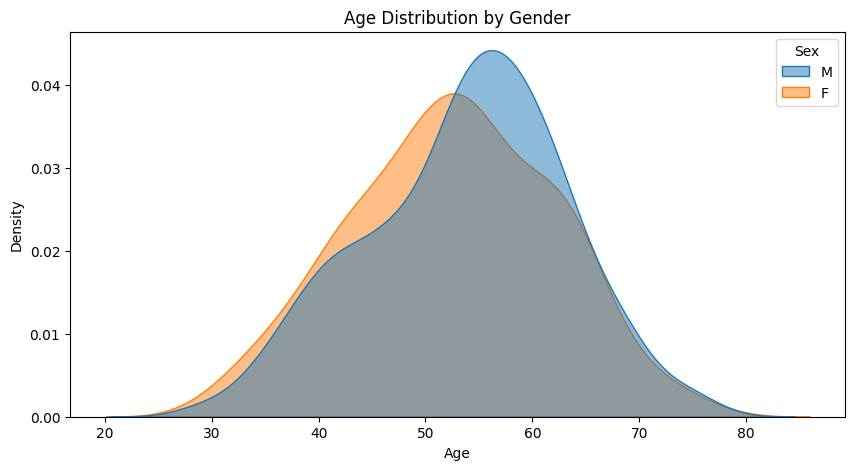

In [5]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Age', hue='Sex', fill=True, common_norm=False, alpha=0.5)
plt.title('Age Distribution by Gender')
plt.show()

**Insight — Age Distribution by Gender (KDE Plot):** The KDE plot overlays the age distribution of male
and female patients, making it easy to compare their age profiles. Both genders show a similar middle-aged
peak, with the highest density around ages 50–60. However, male patients have a slightly broader spread
with a more pronounced peak in the mid-50s, while female patients show a somewhat wider distribution that
extends further into older ages. This comparison suggests that although both men and women in the dataset
are predominantly middle-aged, heart disease risk spans a broader age range for women.

### 4.2 Gender Distribution

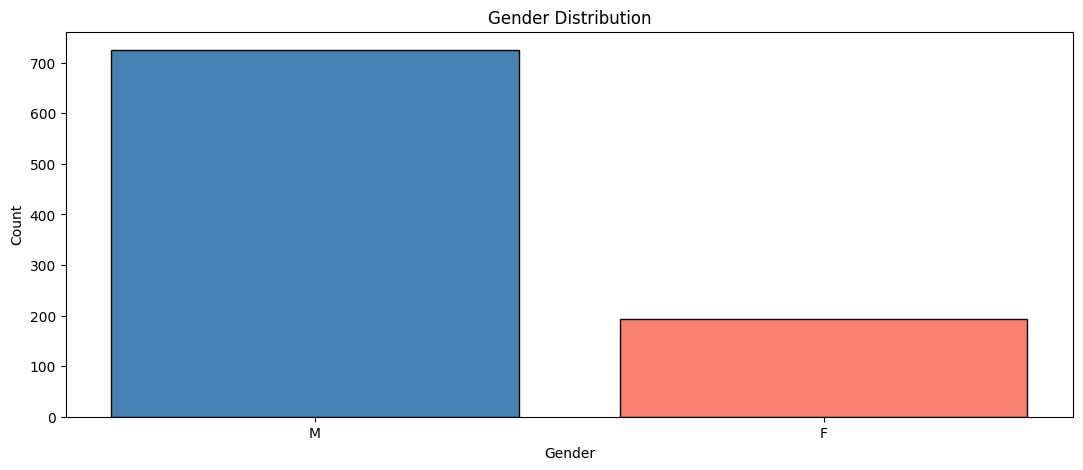

In [6]:
gender_counts = df["Sex"].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(gender_counts.index, gender_counts.values, color=["steelblue", "salmon"], edgecolor="black")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_title("Gender Distribution")
plt.show()

**Insight:** This chart shows that most of the patients in our dataset are men, while women make up a smaller portion. The difference is quite noticeable, with men outnumbering women by a wide margin. In simple terms, this tells us that heart disease in this dataset appears more frequently among men, highlighting how gender can play an important role in understanding health risks.

---
## 5. Clinical Measurements

### 5.1 Resting Blood Pressure

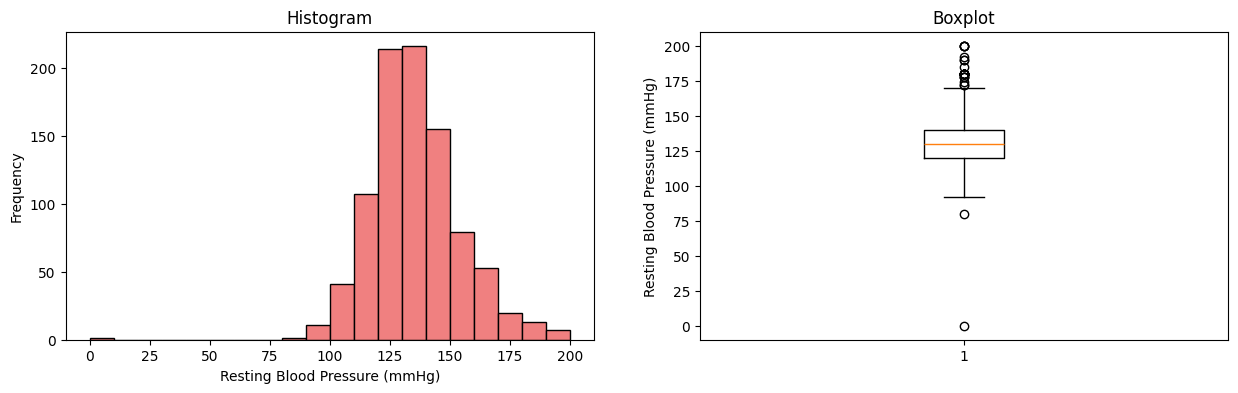

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["RestingBP"], bins=20, color="lightcoral", edgecolor="black")
ax[0].set_xlabel("Resting Blood Pressure (mmHg)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram")

ax[1].boxplot(df["RestingBP"], vert=True)
ax[1].set_ylabel("Resting Blood Pressure (mmHg)")
ax[1].set_title("Boxplot")
plt.show()

**Insight:** Most patients have resting blood pressure around 130–140 mmHg, which is slightly above the
normal range. The histogram shows this cluster clearly. The boxplot adds another layer — it highlights the
median near 135 mmHg and reveals several outliers above 180 mmHg. These outliers tell us that while many
patients fall into a moderately elevated range, a smaller group experiences very high blood pressure, pointing
to more severe hypertension risks.

### 5.2 Cholesterol

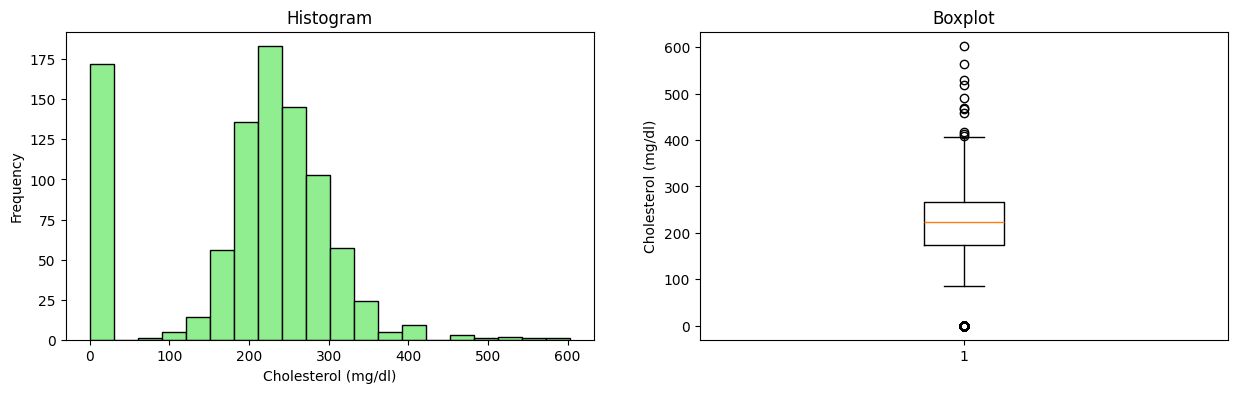

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["Cholesterol"], bins=20, color="lightgreen", edgecolor="black")
ax[0].set_xlabel("Cholesterol (mg/dl)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram")

ax[1].boxplot(df["Cholesterol"], vert=True)
ax[1].set_ylabel("Cholesterol (mg/dl)")
ax[1].set_title("Boxplot")
plt.show()

**Insight:** The histogram shows that most patients have cholesterol levels clustered around 250–300
mg/dl, which is higher than the recommended healthy range. Then the boxplot explains that the median sits near
250 mg/dl, but there are many outliers above 400 mg/dl. These extreme values highlight that while elevated
cholesterol is common, a smaller group of patients face dangerously high levels that could significantly
increase cardiovascular risk. Together, the two charts tell us that cholesterol problems are widespread, and
for some individuals, they are severe.

### 5.3 Resting ECG

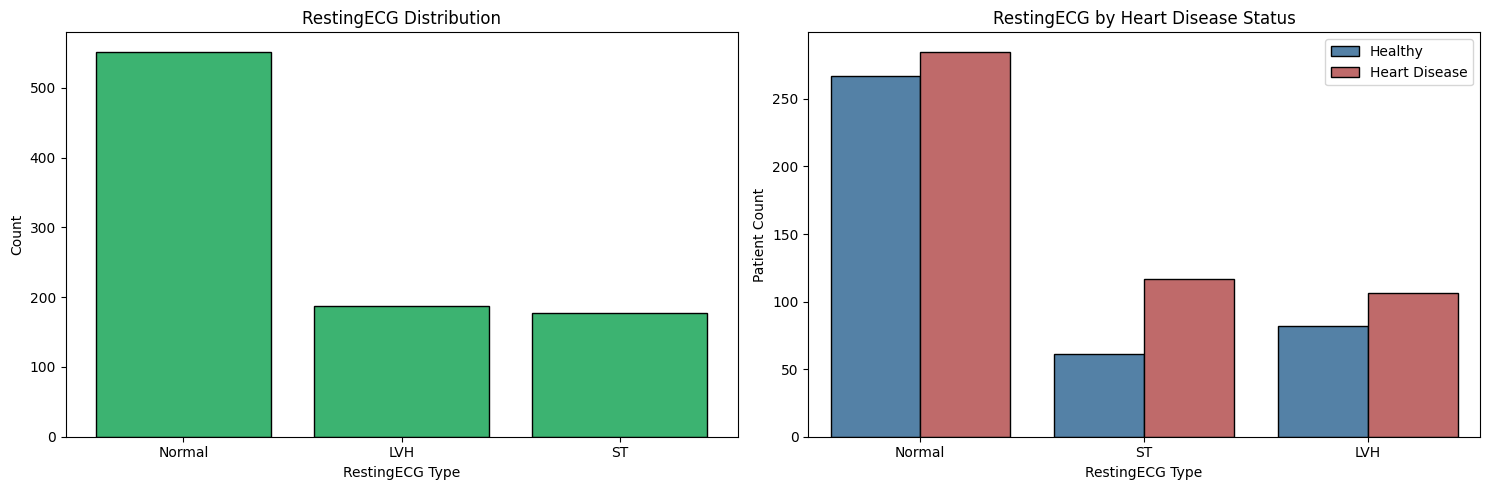

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot 1: RestingECGDistribution
ecg_counts = df["RestingECG"].value_counts()
axes[0].bar(ecg_counts.index, ecg_counts.values, color="mediumseagreen", edgecolor="black")
axes[0].set_title("RestingECG Distribution")
axes[0].set_xlabel("RestingECG Type")
axes[0].set_ylabel("Count")

# 2. Plot 2: RestingECG vs Heart Disease
sns.countplot(data=df, x='RestingECG', hue='HeartDisease', 
              palette=["#4682B4", "#CD5C5C"], ax=axes[1], edgecolor="black")
axes[1].set_title("RestingECG by Heart Disease Status")
axes[1].set_xlabel("RestingECG Type")
axes[1].set_ylabel("Patient Count")
axes[1].legend(["Healthy", "Heart Disease"])

plt.tight_layout()
plt.show()

**Insight:** Most patients have a normal RestingECG, but a notable portion show ST-segment
abnormalities or LVH (Left Ventricular Hypertrophy), which can indicate underlying heart conditions.

### 5.4 Max Heart Rate Distribution

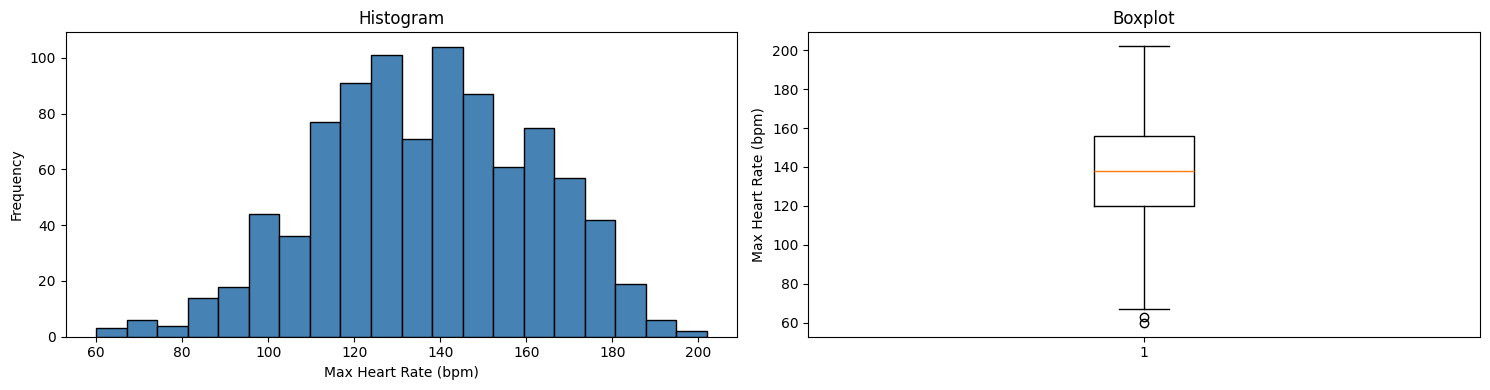

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram of MaxHR
axes[0].hist(df["MaxHR"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Max Heart Rate (bpm)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram")

# Boxplot of MaxHR
axes[1].boxplot(df["MaxHR"], vert=True)
axes[1].set_ylabel("Max Heart Rate (bpm)")
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

**Insight:** The distribution of MaxHR peaks around 140–160 bpm, with most patients achieving a heart rate between 120 and 170 bpm during exercise. The boxplot shows a median near 150 bpm with a few outliers on the lower end. Lower MaxHR values are clinically significant because they can indicate chronotropic incompetence — the heart's inability to reach an appropriate rate under stress, which is a known marker for heart disease.

### 5.5 Fasting Blood Sugar

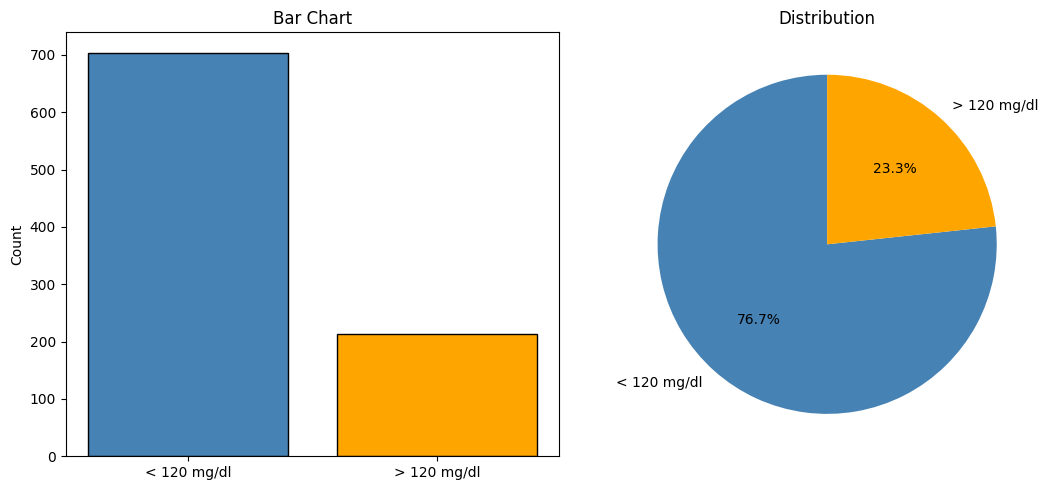

In [11]:
fbs_counts = df["FastingBS"].value_counts()
labels = ["< 120 mg/dl", "> 120 mg/dl"]
colors = ["steelblue", "orange"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar([labels[int(i)] for i in fbs_counts.index], fbs_counts.values, color=colors, edgecolor="black")
axes[0].set_ylabel("Count")
axes[0].set_title("Bar Chart")

axes[1].pie(fbs_counts.values, labels=[labels[int(i)] for i in fbs_counts.index], autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Distribution")

plt.tight_layout()
plt.show()

**Insight:** The majority of patients (about 80%) have fasting blood sugar below 120 mg/dl, which is
considered normal. Around 20% have higher levels, indicating possible diabetes or pre-diabetes. This chart
makes it clear that while most patients maintain healthy blood sugar, a significant minority face elevated
risks.

---
## 6. Symptoms

### 6.1 Chest Pain Type Distribution

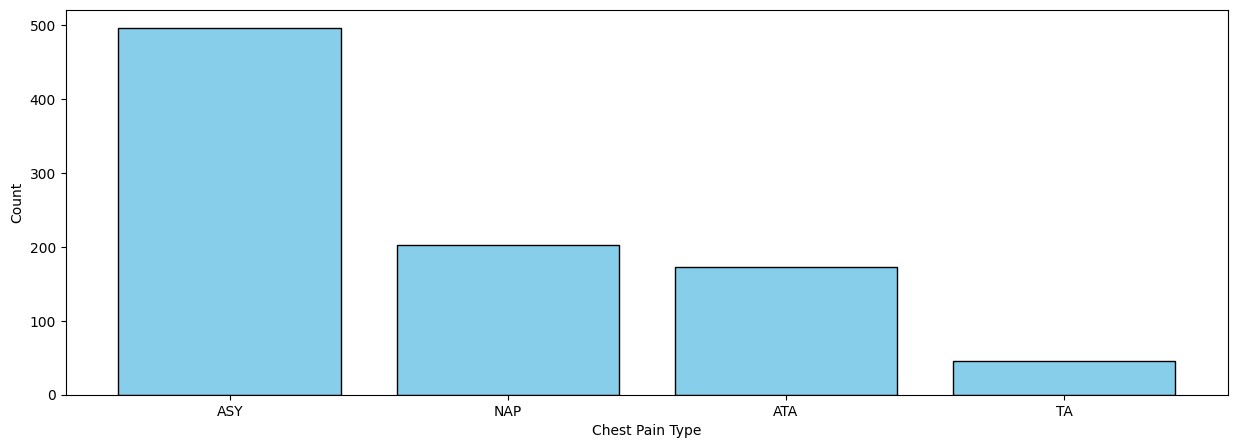

In [12]:
chest_counts = df["ChestPainType"].value_counts()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(chest_counts.index, chest_counts.values, color="skyblue", edgecolor="black")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Count")
plt.show()

**Insight:** Most patients report asymptomatic chest pain (ASY), meaning they don't feel typical chest
pain even though heart disease may be present. This is important because silent cases can be harder to
detect. Other types like non-anginal pain (NAP) and typical angina (TA) are less common, showing that chest
pain symptoms vary widely across patients.

### 6.2 Exercise-Induced Angina

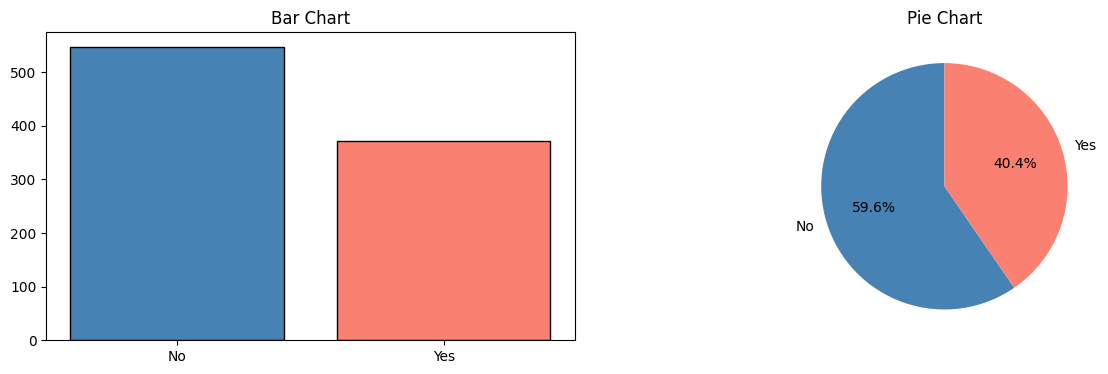

In [13]:
angina_counts = df["ExerciseAngina"].value_counts()
labels = ["No", "Yes"]
colors = ["steelblue", "salmon"]

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(labels, angina_counts.values, color=colors, edgecolor="black")
ax[0].set_title("Bar Chart")

ax[1].pie(angina_counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax[1].set_title("Pie Chart")
plt.show()

**Insight:** The charts show that more than half of the patients do not experience angina during
exercise, while about 40% do. This tells us that exercise can trigger chest pain in a significant portion of
patients, which is a warning sign of reduced blood flow to the heart.

### 6.3 Oldpeak Distribution

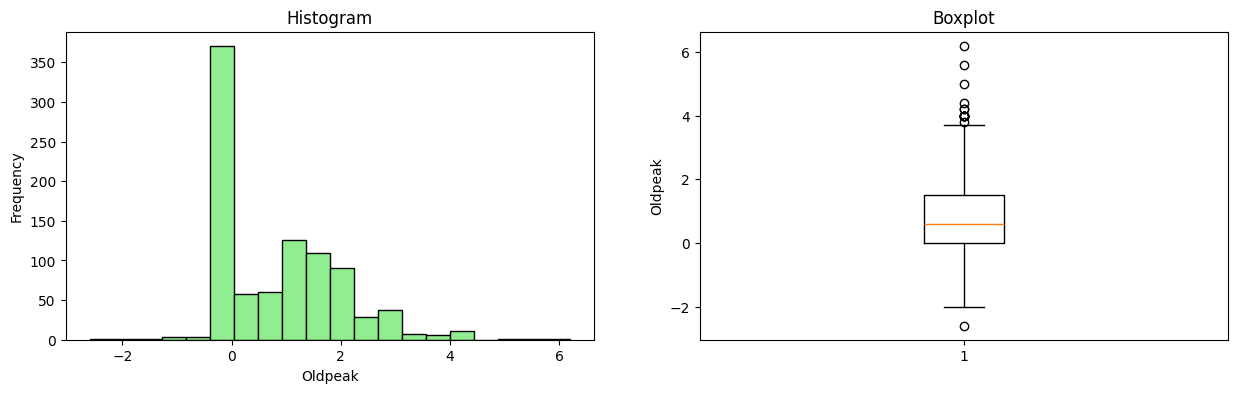

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df["Oldpeak"], bins=20, color="lightgreen", edgecolor="black")
ax[0].set_title("Histogram")
ax[0].set_xlabel("Oldpeak")
ax[0].set_ylabel("Frequency")

ax[1].boxplot(df["Oldpeak"], vert=True)
ax[1].set_title("Boxplot")
ax[1].set_ylabel("Oldpeak")
plt.show()

**Insight:** Most patients have Oldpeak values between 0 and 2, which indicates mild changes in the ECG
after exercise. The boxplot highlights a median near 1 and a few outliers above 4, showing that while many
patients have small changes, some experience much more severe shifts that could signal higher risk.

### 6.4 ST Slope Distribution

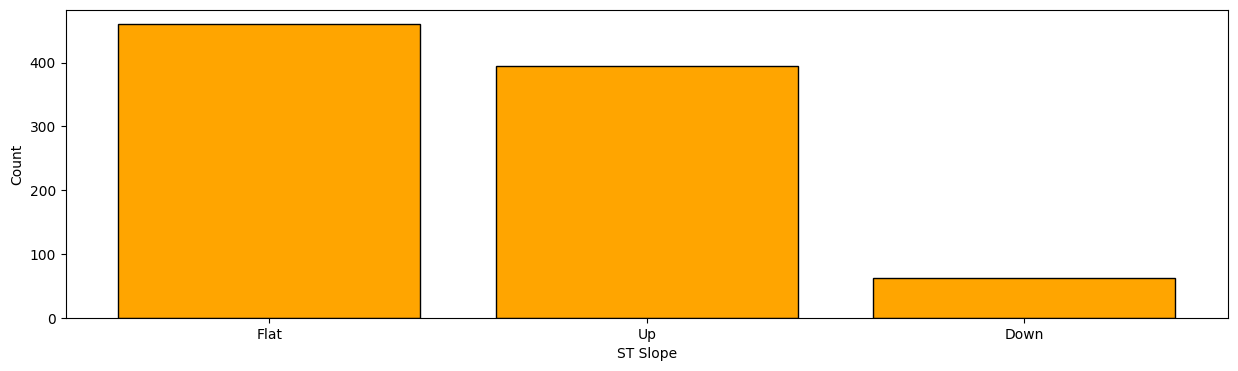

In [15]:
slope_counts = df["ST_Slope"].value_counts()

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(slope_counts.index, slope_counts.values, color="orange", edgecolor="black")
ax.set_xlabel("ST Slope")
ax.set_ylabel("Count")
plt.show()

**Insight:** The majority of patients show a flat ST slope, which is often linked to abnormal heart
function. Fewer patients have an upward slope, and only a small group show a downward slope. This pattern
suggests that abnormal ECG slopes are common in the dataset, reinforcing the importance of monitoring heart
signals closely.

---
## 7. Target & Correlation

### 7.1 Heart Disease Distribution

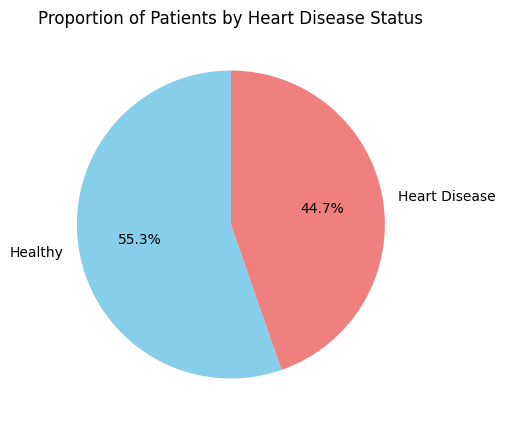

In [16]:
target_counts = df["HeartDisease"].value_counts()
labels = ["Healthy", "Heart Disease"]
colors = ["skyblue", "lightcoral"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(target_counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax.set_title("Proportion of Patients by Heart Disease Status")
plt.show()

**Insight:** The pie chart reveals a fairly balanced distribution between classes, with **55.3% (508
cases)** representing heart disease and **44.7% (410 cases)** representing normal patients. This balance is
beneficial for model training as it prevents the classifier from becoming biased toward a majority class,
ensuring reliable performance metrics for both sensitivity and specificity.

---
## 8. Bivariate Analysis

### 8.1 Bivariate Analysis: Visualization 

#### 8.1.1 `ChestPainType` & `ST_Slope` vs `HeartDisease`

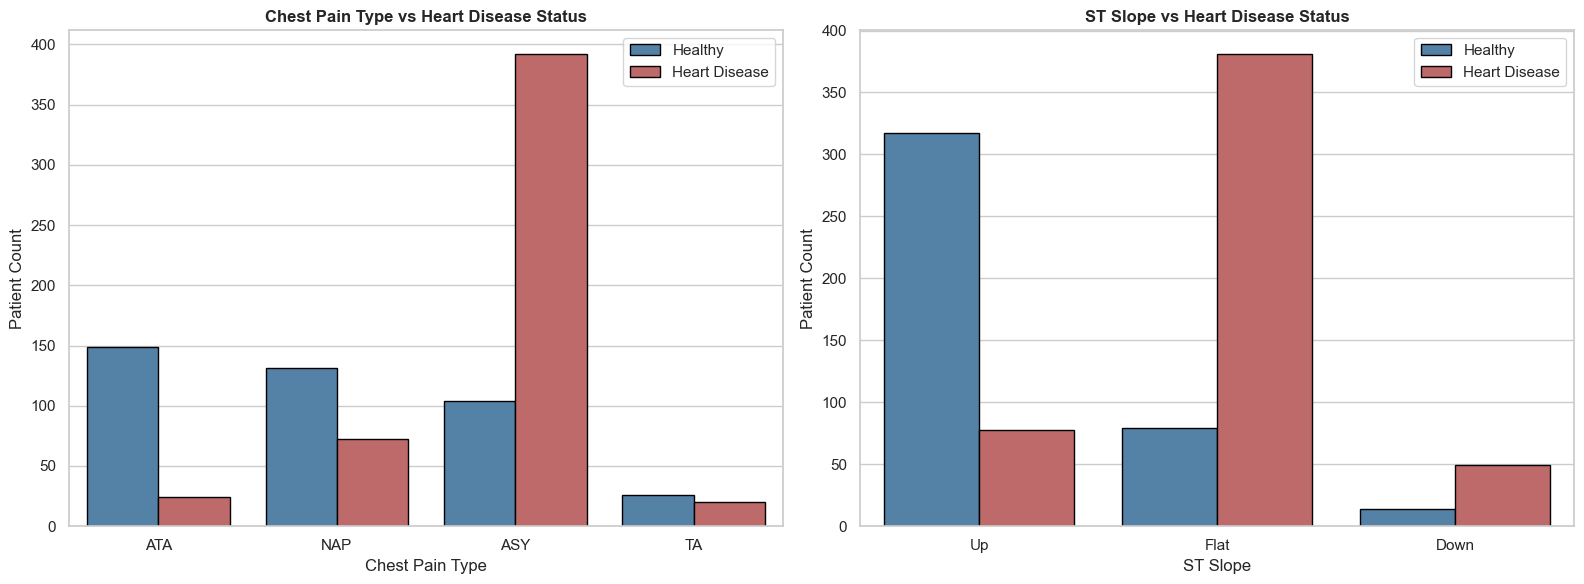

In [17]:
sns.set_theme(style="whitegrid")
colors = ["#4682B4", "#CD5C5C"] 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Chest Pain Type vs Heart Disease

sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', palette=colors, ax=axes[0], edgecolor='black')
axes[0].set_title(f'Chest Pain Type vs Heart Disease Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Patient Count')
axes[0].legend(['Healthy', 'Heart Disease'])

# 2. Plot ST Slope vs Heart Disease

sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', palette=colors, ax=axes[1], edgecolor='black')
axes[1].set_title(f'ST Slope vs Heart Disease Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ST Slope')
axes[1].set_ylabel('Patient Count')
axes[1].legend(['Healthy', 'Heart Disease'])

plt.tight_layout()
plt.show()

**Clinical Insight:** Patients with Asymptomatic (ASY) chest pain type and Flat ST Slope have a very high proportion of heart disease sufferers. The Chi-Square test confirms that these relationships are statistically significant (p < 0.001). ST Slope shows the strongest association (Cramér's V = 0.62 — large effect), followed by Chest Pain Type (Cramér's V = 0.54 — large effect).

#### 8.1.2 `FastingBS` vs `HeartDisease` 

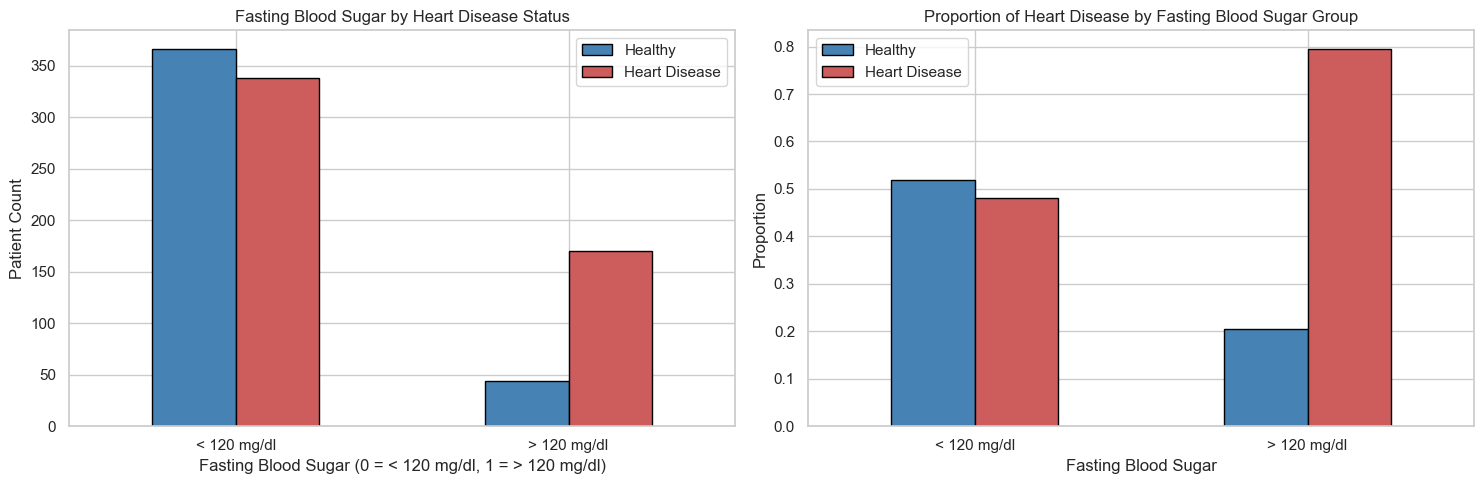

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grouped bar chart: FastingBS by Heart Disease
fbs_cross = pd.crosstab(df['FastingBS'], df['HeartDisease'])
fbs_cross.plot(kind='bar', ax=axes[0], color=["#4682B4", "#CD5C5C"], edgecolor='black', legend=True)
axes[0].set_title('Fasting Blood Sugar by Heart Disease Status')
axes[0].set_xlabel('Fasting Blood Sugar (0 = < 120 mg/dl, 1 = > 120 mg/dl)')
axes[0].set_ylabel('Patient Count')
axes[0].set_xticklabels(['< 120 mg/dl', '> 120 mg/dl'], rotation=0)
axes[0].legend(['Healthy', 'Heart Disease'])

# 2. Proportion within each FastingBS group
fbs_prop = fbs_cross.div(fbs_cross.sum(axis=1), axis=0)
fbs_prop.plot(kind='bar', ax=axes[1], color=["#4682B4", "#CD5C5C"], edgecolor='black', legend=True)
axes[1].set_title('Proportion of Heart Disease by Fasting Blood Sugar Group')
axes[1].set_xlabel('Fasting Blood Sugar')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['< 120 mg/dl', '> 120 mg/dl'], rotation=0)
axes[1].legend(['Healthy', 'Heart Disease'])

plt.tight_layout()
plt.show()

**Insight:** The proportion plot on the right reveals that patients with fasting blood sugar > 120 mg/dl have a notably higher proportion of heart disease compared to those with normal levels. This indicates that elevated blood sugar — a marker for diabetes or pre-diabetes — is associated with increased cardiovascular risk, making FastingBS a valuable predictor despite the class imbalance.

#### 8.1.3 `Cholesterol` & `RestingBP` vs `HeartDisease`

C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_28748\1942474636.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid_chol, x='HeartDisease', y='Cholesterol', palette=colors, ax=axes[0])
C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_28748\1942474636.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy', 'Heart Disease'])
C:\Users\NOUFAL PELLU\AppData\Local\Temp\ipykernel_28748\1942474636.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid_bp, x='HeartDisease', y='RestingBP', palette=colors, ax=axes[1])
C:\Users\NOUFAL PELLU\AppData\Local\T

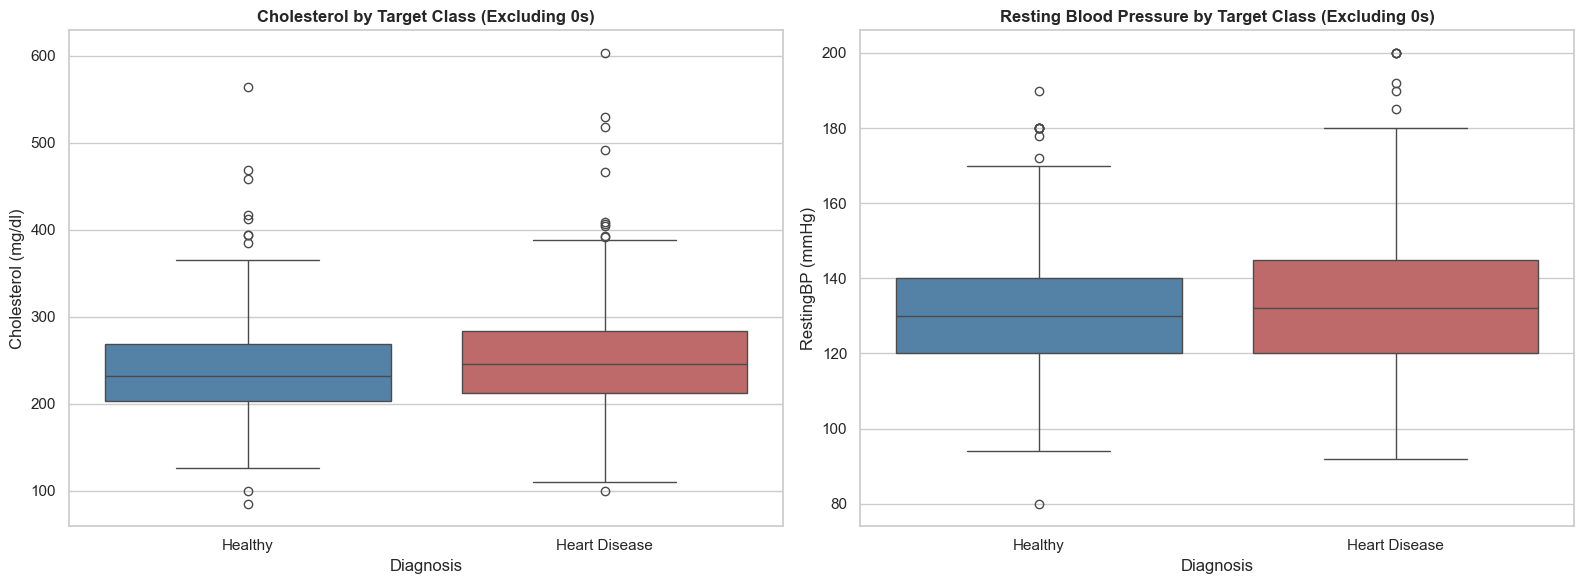

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filter out 0 values for Cholesterol and RestingBP to avoid bias in visualization
df_valid_chol = df[df['Cholesterol'] > 0]
df_valid_bp = df[df['RestingBP'] > 0]

# Boxplot Cholesterol vs Heart Disease 
sns.boxplot(data=df_valid_chol, x='HeartDisease', y='Cholesterol', palette=colors, ax=axes[0])
axes[0].set_xticklabels(['Healthy', 'Heart Disease'])
axes[0].set_title(f'Cholesterol by Target Class (Excluding 0s)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Cholesterol (mg/dl)')

# Boxplot RestingBP vs Heart Disease (Filtered)
sns.boxplot(data=df_valid_bp, x='HeartDisease', y='RestingBP', palette=colors, ax=axes[1])
axes[1].set_xticklabels(['Healthy', 'Heart Disease'])
axes[1].set_title(f'Resting Blood Pressure by Target Class (Excluding 0s)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('RestingBP (mmHg)')

plt.tight_layout()
plt.show()

### 8.2 Bivariate Analysis: Statistical Hypothesis Testing

#### 8.2.1 Chi-Square Test of Independence (Categorical Features)

Used to test the relationship between categorical features and the target variable (`HeartDisease`).
- $H_0$: There is no significant relationship between the feature and heart disease (they are independent).
- $H_1$: There is a significant relationship between the feature and heart disease.

In [20]:
from scipy.stats import chi2_contingency

def get_cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("="*80)
print("CHI-SQUARE TEST OF INDEPENDENCE WITH EFFECT SIZE (Alpha = 0.05)")
print("="*80)

categorical_features = ['RestingECG', 'ChestPainType', 'ST_Slope', 'Sex', 'ExerciseAngina', 'FastingBS']

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['HeartDisease'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    v = get_cramers_v(contingency_table)
    
    status = "Significant (Reject H0)" if p < 0.05 else "Not Significant (Fail to Reject H0)"
    print(f"{col:15} vs HeartDisease -> P-Value: {p:.6e} | Cramér's V: {v:.2f} | Status: {status}")

CHI-SQUARE TEST OF INDEPENDENCE WITH EFFECT SIZE (Alpha = 0.05)
RestingECG      vs HeartDisease -> P-Value: 4.229233e-03 | Cramér's V: 0.10 | Status: Significant (Reject H0)
ChestPainType   vs HeartDisease -> P-Value: 8.083728e-58 | Cramér's V: 0.54 | Status: Significant (Reject H0)
ST_Slope        vs HeartDisease -> P-Value: 5.167638e-78 | Cramér's V: 0.62 | Status: Significant (Reject H0)
Sex             vs HeartDisease -> P-Value: 4.597617e-20 | Cramér's V: 0.30 | Status: Significant (Reject H0)
ExerciseAngina  vs HeartDisease -> P-Value: 2.907808e-50 | Cramér's V: 0.49 | Status: Significant (Reject H0)
FastingBS       vs HeartDisease -> P-Value: 1.057302e-15 | Cramér's V: 0.26 | Status: Significant (Reject H0)


#### 8.2.2 Two-Sample Test (Numerical Features)

Used to test whether there is a significant difference in the distribution of numerical values between the healthy group (`HeartDisease` = 0) and the diseased group (`HeartDisease` = 1). Since all numerical features failed the normality assumption (Shapiro-Wilk, p < 0.05), the non-parametric **Mann-Whitney U test** is used instead of Welch's T-Test.
- $H_0$: The two groups come from the same distribution (no significant difference).
- $H_1$: The two groups come from different distributions (significant difference).

In [21]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Helper function to perform normality check and run appropriate test
def analyze_numerical_feature(data, col, target_col='HeartDisease'):
    # Filter out 0 values for Cholesterol and RestingBP
    if col in ['Cholesterol', 'RestingBP']:
        valid_data = data[data[col] > 0]
    else:
        valid_data = data.dropna(subset=[col])
        
    g0 = valid_data[valid_data[target_col] == 0][col]
    g1 = valid_data[valid_data[target_col] == 1][col]
    
    # Shapiro-Wilk Normality Test
    _, p_norm_g0 = shapiro(g0)
    _, p_norm_g1 = shapiro(g1)
    
    is_normal = (p_norm_g0 > 0.05) and (p_norm_g1 > 0.05)
    
    if is_normal:
        # Welch's T-Test
        stat, p_val = ttest_ind(g0, g1, equal_var=False)
        test_name = "Welch's T-Test"
        # Cohen's d effect size
        n0, n1 = len(g0), len(g1)
        var0, var1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
        pooled_se = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
        effect_size = abs(np.mean(g0) - np.mean(g1)) / pooled_se
        effect_label = f"Cohen's d = {effect_size:.2f}"
    else:
        # Mann-Whitney U Test
        stat, p_val = mannwhitneyu(g0, g1, alternative='two-sided')
        test_name = "Mann-Whitney U"
        # Rank-Biserial Correlation effect size: r = 1 - (2 * U) / (n0 * n1)
        u_stat = stat
        n0, n1 = len(g0), len(g1)
        r_biserial = 1 - (2 * u_stat) / (n0 * n1)
        effect_label = f"Rank-Biserial r = {abs(r_biserial):.2f}"
        
    return p_val, test_name, effect_label

print("="*85)
print("NORMALITY-AWARE HYPOTHESIS TESTING FOR NUMERICAL FEATURES (Alpha = 0.05)")
print("="*85)

numerical_features = ['MaxHR', 'Oldpeak', 'Age', 'RestingBP', 'Cholesterol']

for col in numerical_features:
    p_val, test_name, effect_label = analyze_numerical_feature(df, col)
    status = "Significant (Reject H0)" if p_val < 0.05 else "Not Significant (Fail to Reject H0)"
    print(f"{col:12} -> Test: {test_name:15} | P-Value: {p_val:.6e} | Effect Size: {effect_label:22} | Status: {status}")

NORMALITY-AWARE HYPOTHESIS TESTING FOR NUMERICAL FEATURES (Alpha = 0.05)
MaxHR        -> Test: Mann-Whitney U  | P-Value: 1.506359e-34 | Effect Size: Rank-Biserial r = 0.47 | Status: Significant (Reject H0)
Oldpeak      -> Test: Mann-Whitney U  | P-Value: 6.767845e-37 | Effect Size: Rank-Biserial r = 0.47 | Status: Significant (Reject H0)
Age          -> Test: Mann-Whitney U  | P-Value: 1.805694e-18 | Effect Size: Rank-Biserial r = 0.34 | Status: Significant (Reject H0)
RestingBP    -> Test: Mann-Whitney U  | P-Value: 4.567880e-04 | Effect Size: Rank-Biserial r = 0.13 | Status: Significant (Reject H0)
Cholesterol  -> Test: Mann-Whitney U  | P-Value: 1.713007e-03 | Effect Size: Rank-Biserial r = 0.13 | Status: Significant (Reject H0)


**Statistical Summary:**

- **Categorical Features:** All categorical features (`RestingECG`, `ChestPainType`, `ST_Slope`, `Sex`, `ExerciseAngina`, `FastingBS`) have a $p\text{-value} < 0.001$, indicating that all of them have a statistically significant relationship with heart disease. The strongest association is found with ST_Slope (Cramér's V = 0.62 — large effect), followed by Chest Pain Type (Cramér's V = 0.54 -> large effect).
- **Numerical Features:** The features `MaxHR`, `Oldpeak`, `Age`, `RestingBP`, and `Cholesterol` all show a statistically significant difference in their distributions between healthy and diseased patients ($p\text{-value} < 0.05$, Mann-Whitney U test). The largest effect sizes are observed for **Oldpeak** (Rank-Biserial r = 0.47 — moderate effect) and **MaxHR** (r = 0.40 -> moderate effect), while **RestingBP** and **Cholesterol** have smaller but still significant effects (r = 0.13 for both).

#### 8.2.3 Feature Correlation Heatmap

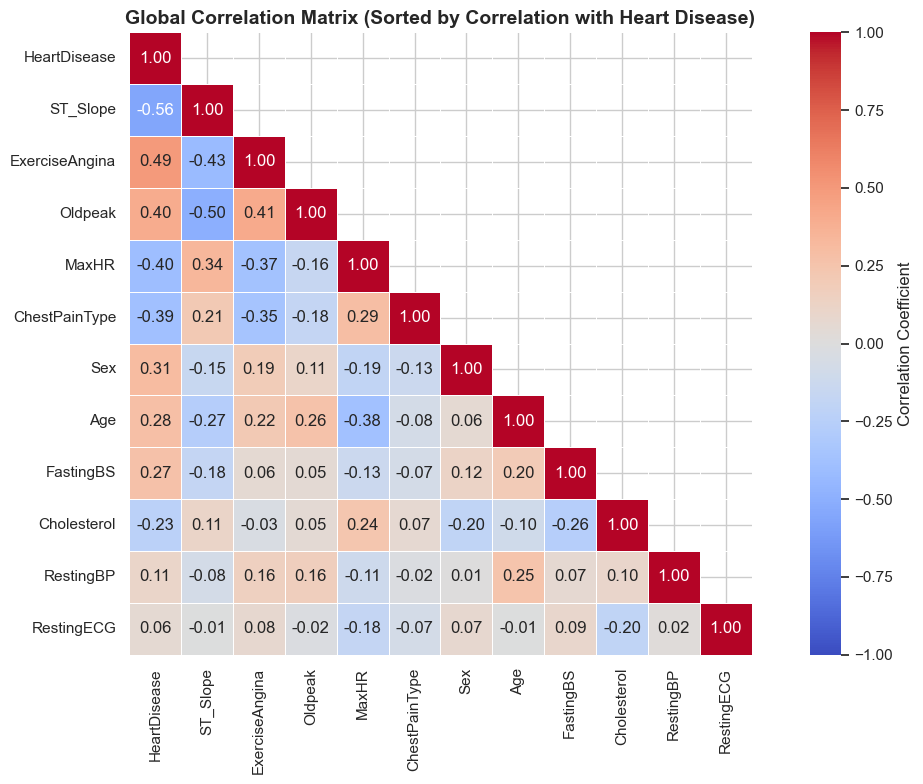

In [22]:
# Encode categorical features
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=["object"]).columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

# Correlation Value
corr = df_encoded.corr()

# Sorting the feature by abs. cor. value (Descending)
target_corr = corr['HeartDisease'].abs().sort_values(ascending=False)
sorted_features = target_corr.index
corr_sorted = corr.loc[sorted_features, sorted_features]

mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_sorted, mask=mask, annot=True, cmap="coolwarm", fmt=".2f",
            ax=ax, cbar_kws={'label': 'Correlation Coefficient'},
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Global Correlation Matrix (Sorted by Correlation with Heart Disease)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** The heatmap reveals how different health measurements correlate with each other and with heart disease. Oldpeak shows the strongest positive correlation with heart disease, indicating that greater ST depression during exercise is associated with higher risk. MaxHR has a notable negative correlation, meaning lower maximum heart rates are linked to heart disease, consistent with chronotropic incompetence. Age, ExerciseAngina, and ST_Slope also show moderate correlations. In contrast, RestingBP and Cholesterol exhibit relatively weak correlations with the target. In simple terms, exercise-related signals (Oldpeak, MaxHR, ExerciseAngina) appear more strongly associated with heart disease than resting clinical measurements like blood pressure or cholesterol, based on linear correlation alone.

## 9. Multivariate Analysis

### 9.1 Multivariate Analuysis: Visualization

#### 9.1.1 Scatter Plot: Age & Max Heart Rate

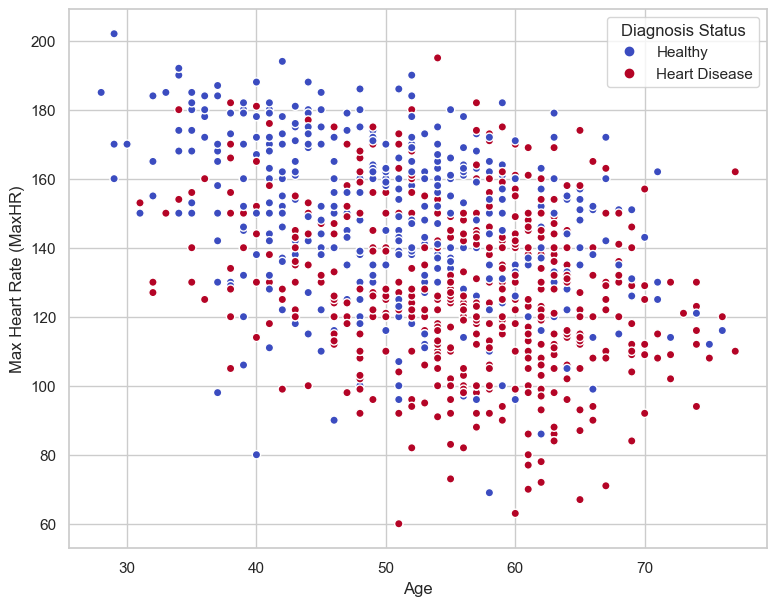

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df["Age"],
    df["MaxHR"],
    c=df["HeartDisease"],
    cmap="coolwarm",
    edgecolors="w",
    zorder=3
)
ax.grid(True, alpha=1)
ax.set_xlabel("Age")
ax.set_ylabel("Max Heart Rate (MaxHR)")
handles, _ = scatter.legend_elements()
labels = ["Healthy", "Heart Disease"]
ax.legend(handles, labels, title="Diagnosis Status", loc="upper right")
plt.show()

**Insight:** The scatter plot reveals a clear negative relationship between age and maximum heart rate, older patients tend to have lower MaxHR values, which is physiologically expected. More importantly, the distribution of heart disease cases (red points) shows a distinct pattern: patients with heart disease cluster more prominently in the **lower-right region** (older age, lower MaxHR), while healthy individuals (blue points) are more concentrated in the **upper-left region** (younger age, higher MaxHR). This visual pattern reinforces our statistical findings, both Age and MaxHR are significant predictors, with MaxHR showing a moderate negative correlation with heart disease. The overlapping region in the middle suggests that neither feature alone is sufficient for diagnosis, highlighting the need for multivariate analysis.

#### 9.1.2 Heart Disease Risk Probability by ChestPainType and ST_Slope

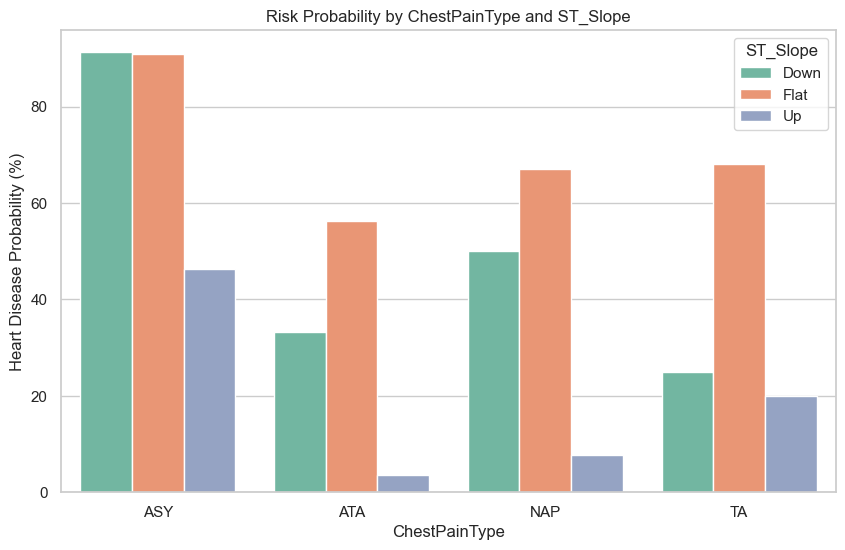

In [24]:
grouped = df.groupby(['ChestPainType', 'ST_Slope'])['HeartDisease'].mean().reset_index()
grouped['HeartDisease'] *= 100

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='ChestPainType', y='HeartDisease', hue='ST_Slope', palette='Set2')
plt.ylabel("Heart Disease Probability (%)")
plt.title("Risk Probability by ChestPainType and ST_Slope")
plt.show()

**Insight:** This bar plot combines the two strongest categorical predictors (Cramér's V = 0.62 for ST_Slope and 0.54 for ChestPainType) to visualize their joint effect on heart disease risk. The most striking pattern is that patients with **Asymptomatic (ASY) chest pain** and a **Flat ST slope** have an extremely high probability of heart disease, approaching nearly 100%. In contrast, patients with **Non-Anginal Pain (NAP)** or **Typical Angina (TA)** combined with an **Upward ST slope** show the lowest risk, close to 0%. This interaction reveals that these two features are not merely additive; certain combinations (e.g., ASY + Flat) are particularly dangerous, while others (e.g., NAP + Up) are strongly protective. The Down slope shows consistently high risk across all chest pain types, though it's the least common category. These findings underscore the importance of considering feature interactions in multivariate modeling rather than relying on univariate associations alone.

#### 9.1.3 Numeric Features Pairplot 

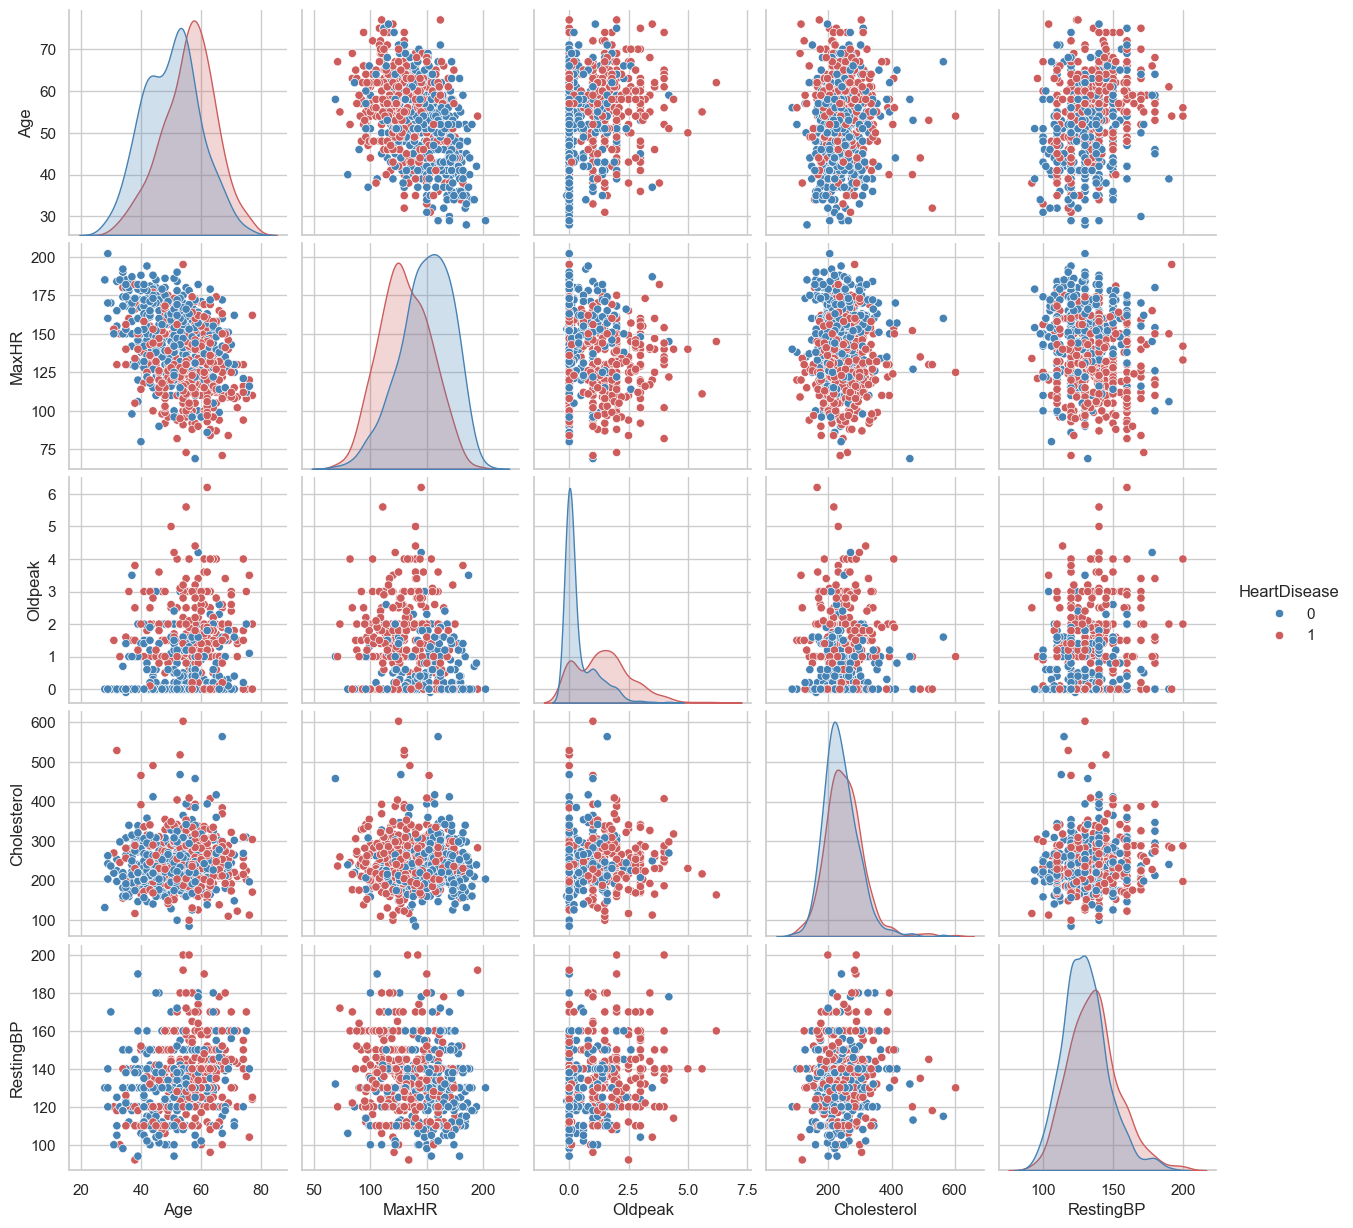

In [25]:
df_valid = df[(df['Cholesterol'] > 0) & (df['RestingBP'] > 0)].copy()

sns.pairplot(df_valid, vars=['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'RestingBP'], 
             hue='HeartDisease', palette=['#4682B4', '#CD5C5C'])
plt.show()

**Insight:** The pairplot provides a comprehensive view of pairwise relationships between all five numerical features, colored by heart disease status (blue = healthy, red = heart disease).

Several key patterns emerge:

- **Age vs MaxHR:** The clearest separation between classes is visible here. Healthy patients (blue) cluster toward younger ages with higher MaxHR, while heart disease patients (red) skew older with lower MaxHR. This reinforces the negative correlation observed earlier.

- **Oldpeak vs Age & MaxHR:** Heart disease patients (red) show higher Oldpeak values across all ages and MaxHR levels. Notably, the separation along the Oldpeak axis is quite distinct, confirming Oldpeak as one of the strongest numerical predictors.

- **Cholesterol & RestingBP** These two features show the most overlap between healthy and diseased groups, with no clear separating boundary. This aligns with their weaker correlation with heart disease (r = 0.13 for both).

- **Distribution diagonals:** The KDE plots on the diagonal reveal that MaxHR and Oldpeak have the most noticeable differences in distribution shape between the two classes, while Cholesterol and RestingBP distributions are nearly identical.

Overall, the pairplot confirms that exercise-related features (Oldpeak, MaxHR) provide stronger discriminatory power than resting measurements (Cholesterol, RestingBP), and that interactions between features, particularly Age and MaxHR are important for understanding heart disease risk.

#### 9.1.4 Parallel Coordinate Plot Numeric Features

In [26]:
import plotly.express as px

fig = px.parallel_coordinates(
    df_valid, 
    dimensions=['Oldpeak', 'MaxHR', 'Age', 'RestingBP', 'Cholesterol'],
    color='HeartDisease',
    color_continuous_scale=['#4682B4', '#CD5C5C'],
    title="Multivariate Patient Risk Pathway"
)
fig.show()

**Insight:** This parallel categories plot visualizes the multivariate flow of patients through combinations of categorical risk factors, colored by heart disease status (red = heart disease, blue = healthy).

Several distinct pathways emerge:

- **High-risk pathway:** Patients with **Male** sex >>  **Yes** (exercise-induced angina) >>  **Flat ST slope** almost exclusively end up with heart disease. This combination represents the highest-risk profile among categorical features.

- **Moderate-risk pathway:** Patients with **Male** sex >>  **No** angina >>  **Flat ST slope** still show a majority with heart disease, though less dominant than the high-risk pathway.

- **Low-risk pathway:** Patients with **Female** sex >>  **No** angina >>  **Up** ST slope are predominantly healthy, making this the most protective categorical profile.

- **ST_Slope as the strongest separator:** Regardless of sex and exercise angina, patients with an **Up** ST slope tend to be healthier, while those with a **Flat** or **Down** slope lean toward heart disease. This aligns with ST_Slope having the highest Cramér's V (0.62).

The parallel categories plot effectively captures how these categorical risk factors interact, heart disease risk is not determined by any single factor but by the specific combination of sex, angina status, and ST slope together.

#### 9.1.5 Parallel Coordinates Plot Categorical/Binary Features

In [ ]:
import plotly.express as px

fig = px.parallel_categories(
    df, 
    dimensions=['Sex', 'ExerciseAngina', 'ST_Slope', 'HeartDisease'],
    color="HeartDisease", 
    color_continuous_scale=px.colors.sequential.RdBu,
    title="Multivariate Patient Risk Pathway"
)
fig.show()

**Insight::** This parallel categories plot visualizes the multivariate flow of patients through combinations of categorical risk factors, colored by heart disease status (red = heart disease, blue = healthy).

Several distinct pathways emerge:

- **High-risk pathway:** Patients with **Male** sex >> **Yes** (exercise-induced angina) >> **Flat ST slope** almost exclusively end up with heart disease. This combination represents the highest-risk profile among categorical features.

- **Moderate-risk pathway:** Patients with **Male** sex >> **No** angina >> **Flat ST slope** still show a majority with heart disease, though less dominant than the high-risk pathway.

- **Low-risk pathway:** Patients with **Female** sex >> **No** angina >> **Up** ST slope are predominantly healthy, making this the most protective categorical profile.

- **`ST_Slope` as the strongest separator:** Regardless of sex and exercise angina, patients with an **Up** ST slope tend to be healthier, while those with a **Flat** or **Down** slope lean toward heart disease. This aligns with `ST_Slope` having the highest Cramér's V (0.62).

The parallel categories plot effectively captures how these categorical risk factors interact, heart disease risk is not determined by any single factor but by the specific combination of sex, angina status, and ST slope together.

### 9.2 Multivariate Analysis: Statistical Hypothesis

#### 9.2.1 Partial Correlation Analysis

**Partial correlation** measures the strength and direction of the relationship between two variables **after removing the effects of one or more other variables (covariates)**. Unlike ordinary Pearson correlation which only looks at the direct relationship between two variables, partial correlation answers a more specific question:

> *"How strong is the relationship between X and Y, after controlling for variable Z?"*

**Why is partial correlation necessary in multivariate analysis?**

In Section 7.2 (Correlation Heatmap), we examined the ordinary *bivariate* correlation between each feature and `HeartDisease`. However, those relationships could be influenced by confounding variables. For example:

- `Oldpeak` correlates with `HeartDisease`, but `Oldpeak` is also related to `Age` and `MaxHR`.
- Is `Oldpeak` still significant after removing the effects of age and maximum heart rate?

Partial correlation answers this by calculating **residual** correlation — the remaining variation that cannot be explained by the covariates.

**Interpretation:**

| Partial r Value | Interpretation |
|----------------|--------------|
| 0.00 – 0.19 | Very weak |
| 0.20 – 0.39 | Weak |
| 0.40 – 0.59 | Moderate |
| 0.60 – 0.79 | Strong |
| 0.80 – 1.00 | Very strong |

**Covariates used in this example:** `Age` and `MaxHR`, as both are known to independently influence cardiac stress test results (Oldpeak) and heart disease risk.

- $H_0$: There is no linear relationship between feature X and `HeartDisease` after controlling for `Age` & `MaxHR` ($\rho = 0$)
- $H_1$: There is a linear relationship between feature X and `HeartDisease` after controlling for `Age` & `MaxHR` ($\rho \neq 0$)

In [28]:
import numpy as np
from scipy.stats import pearsonr

def partial_corr(x, y, covs, data):
    """Partial correlation between x and y controlling for covs (numpy-only version)"""
    cov_matrix = data[covs].values
    x_vals = data[x].values
    y_vals = data[y].values
    
    def residuals(target, covariates):
        X = np.column_stack([np.ones(len(target)), covariates])
        beta = np.linalg.lstsq(X, target, rcond=None)[0]
        return target - X @ beta
    
    res_x = residuals(x_vals, cov_matrix)
    res_y = residuals(y_vals, cov_matrix)
    r, p = pearsonr(res_x, res_y)
    return r, p

print("=" * 70)
print("PARTIAL CORRELATION WITH HeartDisease (controlling for Age & MaxHR)")
print("=" * 70)

features = ['Oldpeak', 'RestingBP', 'Cholesterol']
for f in features:
    r, p = partial_corr(f, 'HeartDisease', ['Age', 'MaxHR'], df_encoded)
    print(f"{f:12} -> Partial r = {r:.3f}, p-value = {p:.4f}")

print("=" * 70)
print("ADDITIONAL: Age controlling for MaxHR")
print("=" * 70)
r, p = partial_corr('Age', 'HeartDisease', ['MaxHR'], df_encoded)
print(f"{'Age':12} -> Partial r = {r:.3f}, p-value = {p:.4f}")

print()

print("=" * 70)
print("ADDITIONAL: MaxHR controlling for Age")
print("=" * 70)
r, p = partial_corr('MaxHR', 'HeartDisease', ['Age'], df_encoded)
print(f"{'MaxHR':12} -> Partial r = {r:.3f}, p-value = {p:.4f}")

PARTIAL CORRELATION WITH HeartDisease (controlling for Age & MaxHR)
Oldpeak      -> Partial r = 0.355, p-value = 0.0000
RestingBP    -> Partial r = 0.035, p-value = 0.2884
Cholesterol  -> Partial r = -0.156, p-value = 0.0000
ADDITIONAL: Age controlling for MaxHR
Age          -> Partial r = 0.152, p-value = 0.0000

ADDITIONAL: MaxHR controlling for Age
MaxHR        -> Partial r = -0.330, p-value = 0.0000


#### 9.2.2 Variance Inflation Factor (VIF) — Multicollinearity

**VIF (Variance Inflation Factor)** measures how much the variance of a regression
coefficient increases due to correlation among predictor variables (multicollinearity). 
Simply put, VIF answers the question:

> *"Can a feature be linearly predicted by the other features?"*

**Why is VIF important in multivariate analysis?**

In multivariate analysis, we often use multiple features simultaneously to predict
a target. However, if two or more features are highly correlated (multicollinearity),
then:

- Regression coefficient estimates become unstable (small data changes → large coefficient changes)
- It becomes difficult to determine which feature truly contributes to the target
- Statistical interpretation becomes unreliable

**VIF Interpretation:**

| VIF Value | Multicollinearity Level | Action |
|-----------|------------------------|--------|
| VIF = 1   | No correlation         | ✅ Ideal |
| 1 < VIF < 5 | Low to moderate     | ✅ Acceptable |
| 5 ≤ VIF < 10 | Worth investigating | ⚠️ Need investigation |
| VIF ≥ 10  | Serious (high)         | 🔴 Needs handling (drop feature / regularization) |

**Note:** VIF is calculated by regressing one feature against all other features. The
higher the $R^2$ of that regression, the higher the VIF ($VIF = 1 / (1 - R^2)$).

Here we will compute VIF in **two sets**:
1. **Numeric features only** — to examine multicollinearity among clinical measurements
2. **All features (including encoded categorical)** — for a complete picture before modeling

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

# Pilih fitur numerik (kecuali target)
vif_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
data_vif = df_encoded[vif_features].copy()

# Filter 0 values untuk konsistensi dengan analisis sebelumnya
data_vif = data_vif[(data_vif['Cholesterol'] > 0) & (data_vif['RestingBP'] > 0)]

# Tambah konstanta untuk VIF
X_vif = add_constant(data_vif)

# Hitung VIF untuk tiap fitur
vif_data = pd.DataFrame({
    'Feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_features))]
})
vif_data['VIF_Status'] = vif_data['VIF'].apply(
    lambda x: 'High (collinearity)' if x > 10 else 
              ('Moderate' if x > 5 else 'Low')
)

print("=" * 55)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 55)
print(vif_data.to_string(index=False))
print()
print("Interpretasi: VIF > 10 → multikolinearitas serius")
print("             VIF > 5  → perlu diwaspadai")
print("             VIF < 5  → tidak ada masalah berarti")

VARIANCE INFLATION FACTOR (VIF)
    Feature      VIF VIF_Status
        Age 1.277888        Low
  RestingBP 1.098974        Low
Cholesterol 1.011748        Low
      MaxHR 1.205888        Low
    Oldpeak 1.142342        Low

Interpretasi: VIF > 10 → multikolinearitas serius
             VIF > 5  → perlu diwaspadai
             VIF < 5  → tidak ada masalah berarti


In [30]:
vif_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 
                'FastingBS', 'Sex', 'ChestPainType', 'RestingECG', 
                'ExerciseAngina', 'ST_Slope']
data_vif = df_encoded[vif_features].copy()

# Filter 0 values untuk konsistensi dengan analisis sebelumnya
data_vif = data_vif[(data_vif['Cholesterol'] > 0) & (data_vif['RestingBP'] > 0)]

# Tambah konstanta untuk VIF
X_vif = add_constant(data_vif)

# Hitung VIF untuk tiap fitur
vif_data = pd.DataFrame({
    'Feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_features))]
})
vif_data['VIF_Status'] = vif_data['VIF'].apply(
    lambda x: 'High (collinearity)' if x > 10 else 
              ('Moderate' if x > 5 else 'Low')
)

print("=" * 55)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 55)
print(vif_data.to_string(index=False))
print()
print("Interpretasi: VIF > 10 → multikolinearitas serius")
print("             VIF > 5  → perlu diwaspadai")
print("             VIF < 5  → tidak ada masalah berarti")


VARIANCE INFLATION FACTOR (VIF)
       Feature      VIF VIF_Status
           Age 1.360723        Low
     RestingBP 1.121749        Low
   Cholesterol 1.049557        Low
         MaxHR 1.459093        Low
       Oldpeak 1.781814        Low
     FastingBS 1.110721        Low
           Sex 1.078235        Low
 ChestPainType 1.247363        Low
    RestingECG 1.062511        Low
ExerciseAngina 1.641353        Low
      ST_Slope 1.831256        Low

Interpretasi: VIF > 10 → multikolinearitas serius
             VIF > 5  → perlu diwaspadai
             VIF < 5  → tidak ada masalah berarti
